In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import svm

## 背景

在该数据模拟的实验中，研究人员对一项广告促销活动进行了测试，以观察它是否能吸引更多顾客购买一款定价为 10 美元的特定产品。由于公司发送每份促销信息的成本为 0.15 美元，因此最好将促销活动仅针对那些对该促销最容易接受的人。每个数据点都包含一列，表明某个个体是否收到了该产品的促销信息，还有一列表明该个体最终是否购买了该产品。每个个体还有另外七个相关特征，这些特征被抽象地表示为 V1 至 V7。

### 评估指标

为了衡量Uplift模型的效果，我们主要关注两个核心指标：增量响应率（IRR）和净增量收入（NIR）。

#### 增量响应率 (Incremental Response Rate - IRR)

IRR衡量的是实验组（Treatment）相对于控制组（Control）在响应率（如购买率、点击率等）上的净提升。它直接反映了干预措施（如发送促销信息）带来的效果。

**公式:**
$$ IRR = \frac{\text{实验组响应数}}{\text{实验组总人数}} - \frac{\text{控制组响应数}}{\text{控制组总人数}} $$

*   **实验组响应数 (Responders_treatment):** 收到促销信息并购买产品的用户数。
*   **实验组总人数 (Total_treatment):** 所有收到促销信息的用户数。
*   **控制组响应数 (Responders_control):** 未收到促销信息但购买产品的用户数。
*   **控制组总人数 (Total_control):** 所有未收到促销信息的用户数。

#### 净增量收入 (Net Incremental Revenue - NIR)

NIR将模型带来的响应率提升转化为实际的经济收益。它计算了由Uplift带来的总收入减去营销活动总成本后的净利润。这是评估模型商业价值的关键指标。

**公式:**
$$ NIR = (\text{IRR} \times \text{目标人群总数}) \times \text{单次转化收入} - \text{目标人群总数} \times \text{单次干预成本} $$

根据我们项目背景的设定：
*   **单次转化收入 (Revenue per Conversion):** 10美元
*   **单次干预成本 (Cost per Treatment):** 0.15美元

因此，对于一个被模型筛选出来并进行干预的用户群体，其NIR可以简化为计算每个用户的期望增量价值。

## Load Data

In [40]:

df_train = pd.read_csv(f'/home/tiger/my_notes/uplift/data/training.csv')
df_test = pd.read_csv(f'/home/tiger/my_notes/uplift/data/Test.csv')
df_test=df_test.iloc[:,:10]
print(df_train.shape, df_test.shape)

(84534, 10) (41650, 10)


/tmp/ipykernel_151803/3235932338.py:2: DtypeWarning: Columns (12,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(f'/home/tiger/my_notes/uplift/data/Test.csv')


In [28]:
df_train.head(5)

,ID,Promotion,purchase,V1,V2,V3,V4,V5,V6,V7
0,1,No,0,2,30.443518,-1.165083,1,1,3,2
1,3,No,0,3,32.159350,-0.645617,2,3,2,2
2,4,No,0,2,30.431659,0.133583,1,1,4,2
3,5,No,0,0,26.588914,-0.212728,2,1,4,2
4,8,Yes,0,3,28.044331,-0.385883,1,1,2,2


In [22]:
#验证treatment分布是均衡的
(df_train["Promotion"]=='Yes').sum()/df_train.shape[0]

np.float64(0.5011474672912675)

对每一个特征，进行分箱，将每个特征的值分为4个等宽的区间，观察每个区间内，促销vs不促销购买产品比例的变化

随机发券：评估测试集发券方式可能带来的增益
根据估计的每一个用户uplift分档次（相当于阈值）选择是否发券：可以带来的增益
比如：能够根据增量价值对客户进行排名，从而精准定位响应度最高的 15-25% 的潜在客户


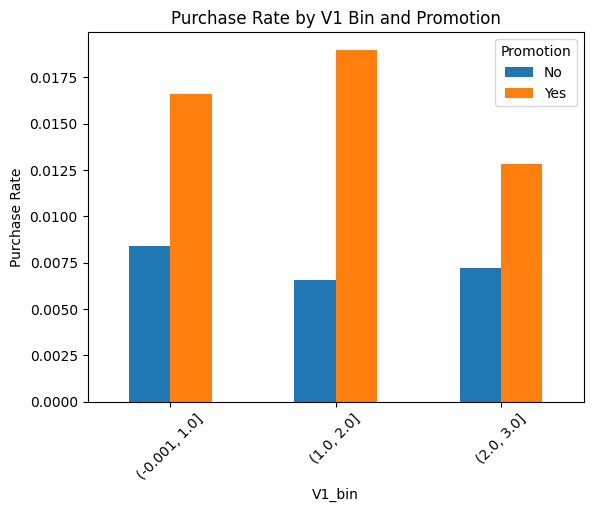

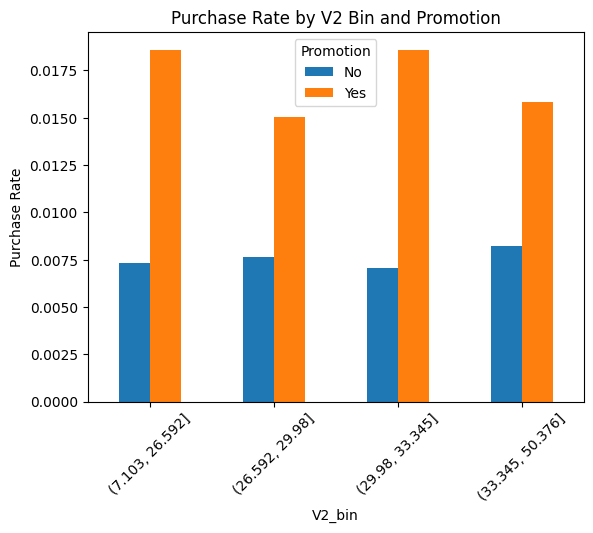

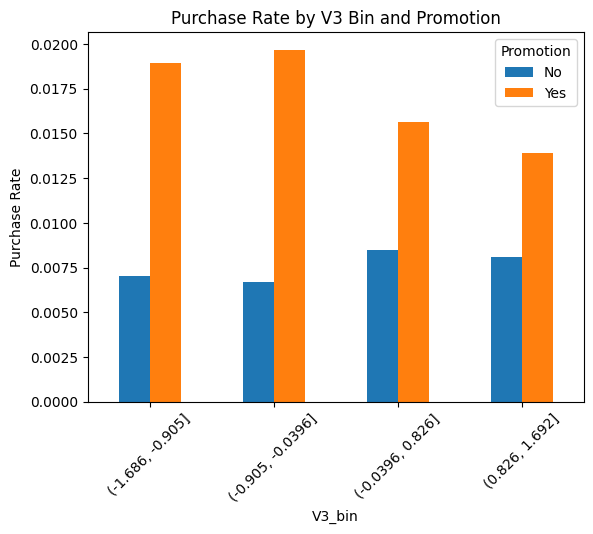

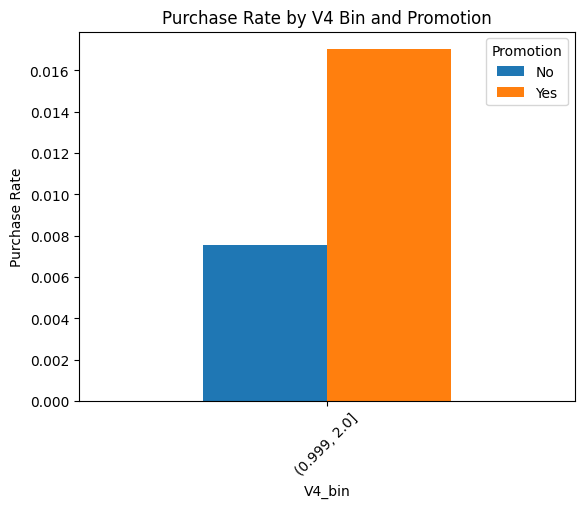

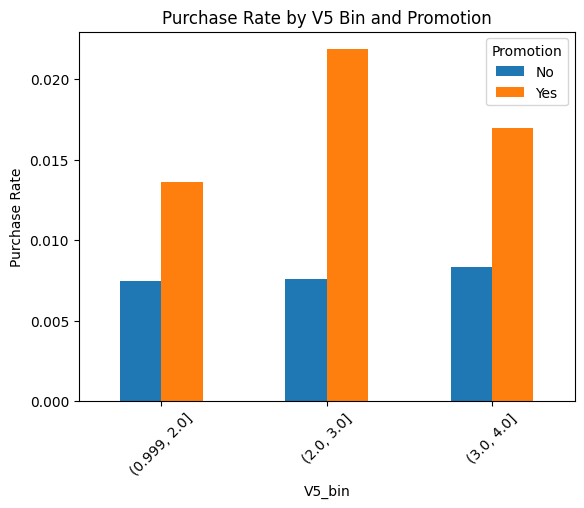

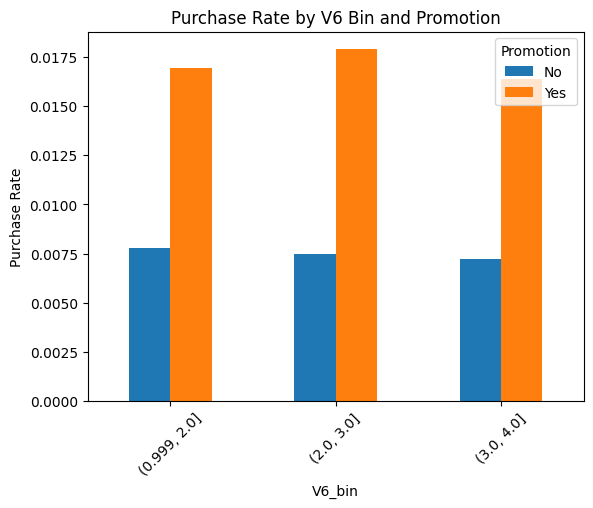

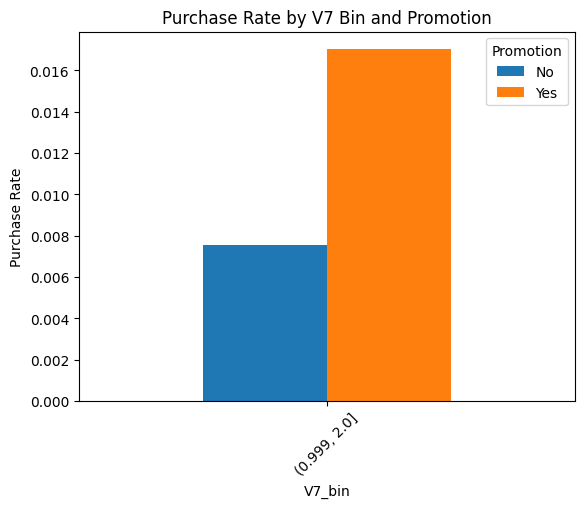

In [19]:
for i in range(1, 8):
  df_train[f'V{i}_bin'] = pd.qcut(df_train[f'V{i}'], q=4, duplicates='drop')

  purchase_by_bin = df_train.groupby([f'V{i}_bin', 'Promotion'], observed=True)['purchase'].mean().unstack()
  purchase_by_bin.plot(kind='bar')
  plt.title(f"Purchase Rate by V{i} Bin and Promotion")
  plt.ylabel("Purchase Rate")
  plt.xticks(rotation=45)
  plt.show()

### Model

是否存在选择性偏差？平衡treated和control组在表示空间中的分布，倾向得分分布很一致

#### XGBoost

In [43]:
cols = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7']

df_treatment = df_train[df_train['Promotion'] == 'Yes']
df_control = df_train[df_train['Promotion'] == 'No']

lst_uplift_irr = []
lst_uplift_nir = []

In [51]:
def calculate_uplift_metrics(results_df, uplift_column, metric_type="uplift", avg_rev_per_purchase=10, cost_per_promo=0.15, n_buckets=10):
    """
    Calculates cumulative uplift metrics for either standard uplift or Net Incremental Revenue (NIR).

    Args:
        results_df (pd.DataFrame): DataFrame containing uplift score, 'purchase', and 'Promotion' columns
        uplift_column (str): Name of the column containing uplift scores
        metric_type (str): Either "uplift" for standard uplift metrics or "nir" for Net Incremental Revenue
        avg_rev_per_purchase (float): Average revenue per purchase (used only for NIR calculations)
        cost_per_promo (float): Cost per promotion/treatment (used only for NIR calculations)
        n_buckets (int): Number of quantiles/deciles to divide the data into

    Returns:
        pd.DataFrame: DataFrame with cumulative metrics per bucket
    """

    # Sort by uplift score in descending order
    df_sorted = results_df.sort_values(by=uplift_column, ascending=False).reset_index(drop=True)

    # Assign each row to a bucket using quantiles
    df_sorted['bucket'] = pd.qcut(df_sorted[uplift_column], q=n_buckets, labels=False, duplicates='drop')

    # Aggregate performance per bucket
    bucket_performance = df_sorted.groupby('bucket').apply(lambda x: pd.Series({
        'total_users': len(x),
        'treated_users': (x['Promotion'] == 'Yes').sum(),
        'control_users': (x['Promotion'] == 'No').sum(),
        'treated_purchases': (x['purchase'][x['Promotion'] == 'Yes']).sum(),
        'control_purchases': (x['purchase'][x['Promotion'] == 'No']).sum()
    }), include_groups=False).reset_index()

    # Handle NaN values that might arise from 0 users in a group
    bucket_performance = bucket_performance.fillna(0)

    # Calculate response rates and incremental metrics per bucket
    bucket_performance['treated_response_rate'] = (
        bucket_performance['treated_purchases'] / bucket_performance['treated_users']
    ).fillna(0)

    bucket_performance['control_response_rate'] = (
        bucket_performance['control_purchases'] / bucket_performance['control_users']
    ).fillna(0)

    bucket_performance['incremental_response_rate'] = (
        bucket_performance['treated_response_rate'] - bucket_performance['control_response_rate']
    )

    # Calculate incremental purchases per bucket
    bucket_performance['incremental_purchases'] = (
        bucket_performance['treated_purchases'] - bucket_performance['control_purchases']
    )

    # Calculate cumulative basic metrics (common to both types)
    bucket_performance['cumulative_users'] = bucket_performance['total_users'].cumsum()
    bucket_performance['percentage_of_population'] = (
        (bucket_performance['cumulative_users'] / bucket_performance['total_users'].sum()) * 100
    )

    bucket_performance['cumulative_treated_purchases'] = bucket_performance['treated_purchases'].cumsum()
    bucket_performance['cumulative_control_purchases'] = bucket_performance['control_purchases'].cumsum()

    # Calculate metric-specific columns
    if metric_type == "nir":
        # NIR-specific calculations
        bucket_performance['incremental_revenue'] = (
            bucket_performance['incremental_purchases'] * avg_rev_per_purchase
        )

        bucket_performance['promotion_cost'] = (
            bucket_performance['treated_users'] * cost_per_promo
        )

        bucket_performance['net_incremental_revenue'] = (
            bucket_performance['incremental_revenue'] - bucket_performance['promotion_cost']
        )

        # Cumulative NIR metrics
        bucket_performance['cumulative_net_incremental_revenue'] = (
            bucket_performance['net_incremental_revenue'].cumsum()
        )

        bucket_performance['cumulative_incremental_revenue'] = (
            bucket_performance['incremental_revenue'].cumsum()
        )

        bucket_performance['cumulative_promotion_cost'] = (
            bucket_performance['promotion_cost'].cumsum()
        )

    else:
        # Standard uplift calculations
        bucket_performance['cumulative_uplift'] = (
            bucket_performance['cumulative_treated_purchases'] -
            bucket_performance['cumulative_control_purchases']
        )

        # Alternative calculation for cumulative uplift (same result, different approach)
        bucket_performance['cumulative_incremental_purchases'] = (
            bucket_performance['incremental_purchases'].cumsum()
        )

    return bucket_performance

def plot_uplift_curve(df, curve_type="qini", avg_revenue_per_purchase=10, cost_per_promo=0.15, title=None, baseline_noise=0.05, return_qini_coef=False, labels=None):
    """
    Plots either a Qini curve (incremental responses) or Net Incremental Revenue (NIR) curve.
    Can handle single DataFrame or list of DataFrames.

    Args:
        df (pd.DataFrame or list): Single DataFrame or list of DataFrames with columns
                                  [treated_users, control_users, treated_purchases, control_purchases]
        curve_type (str): Either "qini" for Qini curve or "nir" for Net Incremental Revenue curve
        avg_revenue_per_purchase (float): Average revenue per purchase (used only for NIR curve)
        cost_per_promo (float): Cost per promotion/treatment (used only for NIR curve)
        title (str): Title for the plot. If None, auto-generates based on curve_type
        baseline_noise (float): Standard deviation for random baseline noise
        return_qini_coef (bool): If True, also returns the Qini coefficient(s)
        labels (list): List of labels for each DataFrame. If None, auto-generates labels

    Returns:
        None: Displays the plot, or float/list if return_qini_coeff=True
    """

    # Convert single DataFrame to list for uniform processing
    if isinstance(df, pd.DataFrame):
        df_list = [df]
        single_df = True
    else:
        df_list = df
        single_df = False

    # Generate default labels if not provided
    if labels is None:
        if single_df:
            labels = ['Model']
        else:
            labels = [f'Model {i+1}' for i in range(len(df_list))]
    elif len(labels) != len(df_list):
        raise ValueError(f"Number of labels ({len(labels)}) must match number of DataFrames ({len(df_list)})")

    # Set default title if not provided
    if title is None:
        title = "Net Incremental Revenue Curve" if curve_type == "nir" else "Uplift Curve (Qini Curve)"

    # Define colors for multiple curves
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

    # Create the plot
    fig, ax1 = plt.subplots(figsize=(10, 6))

    qini_coefficients = []
    baseline_plotted = False

    for idx, (current_df, label) in enumerate(zip(df_list, labels)):
        color = colors[idx % len(colors)]

        # Extract data from DataFrame
        treated_users = current_df.loc[:, 'treated_users'].values
        control_users = current_df.loc[:, 'control_users'].values
        treated_purchases = current_df.loc[:, 'treated_purchases'].values
        control_purchases = current_df.loc[:, 'control_purchases'].values

        # Calculate conversion rates (handle division by zero)
        treated_conv_rate = np.divide(treated_purchases, treated_users,
                                     out=np.zeros_like(treated_purchases, dtype=float),
                                     where=treated_users!=0)
        control_conv_rate = np.divide(control_purchases, control_users,
                                     out=np.zeros_like(control_purchases, dtype=float),
                                     where=control_users!=0)

        # Calculate uplift score (difference in conversion rates)
        uplift_score = treated_conv_rate - control_conv_rate

        # Create DataFrame for sorting by uplift score
        df_with_uplift = pd.DataFrame({
            'treated_users': treated_users,
            'control_users': control_users,
            'treated_purchases': treated_purchases,
            'control_purchases': control_purchases,
            'uplift_score': uplift_score
        })

        # Sort by uplift score (descending - highest uplift first)
        df_sorted = df_with_uplift.sort_values('uplift_score', ascending=False).reset_index(drop=True)

        # Calculate incremental responses for each segment
        control_rate_for_treated = np.divide(df_sorted['control_purchases'], df_sorted['control_users'],
                                            out=np.zeros_like(df_sorted['control_purchases'], dtype=float),
                                            where=df_sorted['control_users']!=0)

        incremental_responses = (df_sorted['treated_purchases'] - (df_sorted['treated_users'] * control_rate_for_treated))

        # Calculate net responses based on curve type
        if curve_type == "nir":
            # For NIR curve: subtract costs in response units
            cost_in_responses = (df_sorted['treated_users'] * cost_per_promo) / avg_revenue_per_purchase
            net_responses = incremental_responses - cost_in_responses
            y_label = 'Cumulative Net Incremental Responses'
        else:
            # For Qini curve: use raw incremental responses
            net_responses = incremental_responses
            y_label = 'Cumulative Incremental Responses'

        # Calculate cumulative metrics
        cumulative_treated_users = df_sorted['treated_users'].cumsum()
        cumulative_responses = net_responses.cumsum()

        # Calculate percentage of population targeted
        total_population = df_sorted['treated_users'].sum()
        pct_population_targeted = (cumulative_treated_users / total_population) * 100

        # For Qini curve only: prepend 0 values to start at origin (0,0)
        if curve_type == "qini":
            pct_population_targeted = pd.concat([pd.Series([0]), pct_population_targeted]).reset_index(drop=True)
            cumulative_responses = pd.concat([pd.Series([0]), cumulative_responses]).reset_index(drop=True)

            # Generate baseline for each DataFrame
        n_points = len(pct_population_targeted)

        # Handle edge case where there are no data points
        if n_points == 0 or (curve_type == "qini" and n_points <= 1):
            raise ValueError("No valid data points found in the dataset")

        if curve_type == "nir":
            # NIR baseline: realistic baseline that starts at 0 and grows based on average performance
            avg_net_response_rate = cumulative_responses.iloc[-1] / total_population if total_population > 0 else 0
            baseline = pct_population_targeted * avg_net_response_rate * (total_population / 100)
            baseline_noise_factor = baseline_noise
        else:
            # Qini baseline: linear baseline representing random targeting
            final_responses = cumulative_responses.iloc[-1]
            baseline = (pct_population_targeted / 100) * final_responses
            baseline_noise_factor = baseline_noise * 0.1  # Reduced noise for Qini to keep it mostly linear

        # Add random variation to baseline
        if baseline_noise > 0:
            baseline_std = np.std(cumulative_responses) if len(cumulative_responses) > 1 else 1.0
            baseline_noise_values = np.random.normal(0, baseline_noise_factor * baseline_std, n_points)
            baseline = baseline + baseline_noise_values

            # Ensure baseline starts at 0 for Qini curve
            if curve_type == "qini":
                baseline[0] = 0

        # Convert to numpy arrays for consistent plotting
        baseline_vals = np.array(baseline)

        # Plot baseline (only once for visual clarity)
        if not baseline_plotted:
            ax1.plot(pct_population_targeted, baseline_vals, 'r--', linewidth=2,
                    label='Random Targeting Baseline', alpha=0.7)
            baseline_plotted = True

        # Convert to numpy arrays for consistent plotting
        x_vals = np.array(pct_population_targeted)
        y_vals = np.array(cumulative_responses)

        # Calculate Qini coefficient if needed
        qini_coefficient = 0
        curve_label = label
        if curve_type == "qini":
            qini_coefficient = np.trapezoid(y_vals - baseline_vals, x_vals / 100)
            qini_coefficients.append(qini_coefficient)
            curve_label += f' (Qini: {qini_coefficient:.2f})'

        # Plot primary curve (responses)
        ax1.plot(x_vals, y_vals, color=color, linewidth=2.5, marker='o', markersize=4,
                label=curve_label, alpha=0.8)

        # Add fill areas for each curve
        uplift_better = y_vals > baseline_vals
        uplift_worse = y_vals <= baseline_vals

        # Use lighter alpha for multiple curves and only add labels for the first curve
        fill_alpha = 0.08 if len(df_list) > 1 else 0.15

        if idx == 0:
            ax1.fill_between(x_vals, y_vals, baseline_vals, alpha=fill_alpha, color='green',
                           where=uplift_better, interpolate=True, label='Uplift > Random')
            ax1.fill_between(x_vals, y_vals, baseline_vals, alpha=fill_alpha, color='red',
                           where=uplift_worse, interpolate=True, label='Uplift ≤ Random')
        else:
            ax1.fill_between(x_vals, y_vals, baseline_vals, alpha=fill_alpha, color='green',
                           where=uplift_better, interpolate=True)
            ax1.fill_between(x_vals, y_vals, baseline_vals, alpha=fill_alpha, color='red',
                           where=uplift_worse, interpolate=True)

    # Add horizontal line at y=0
    ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.5, linewidth=1)

    # Set labels and formatting
    ax1.set_xlabel('Percentage of Population Targeted (Ordered by Uplift Score)', fontsize=12)
    ax1.set_ylabel(y_label, fontsize=12)
    ax1.tick_params(axis='y')
    ax1.set_xlim(0, 100)
    ax1.grid(True, alpha=0.3)

    # Add secondary axis only for NIR
    if curve_type == "nir":
        ax2 = ax1.twinx()
        ax2.set_ylabel('Cumulative Net Incremental Revenue ($)', fontsize=12)

        # Plot revenue curves for each model
        for idx, (current_df, label) in enumerate(zip(df_list, labels)):
            color = colors[idx % len(colors)]
            # Recalculate y_vals for this specific dataframe (simplified version)
            treated_users = current_df.loc[:, 'treated_users'].values
            control_users = current_df.loc[:, 'control_users'].values
            treated_purchases = current_df.loc[:, 'treated_purchases'].values
            control_purchases = current_df.loc[:, 'control_purchases'].values

            treated_conv_rate = np.divide(treated_purchases, treated_users,
                                         out=np.zeros_like(treated_purchases, dtype=float),
                                         where=treated_users!=0)
            control_conv_rate = np.divide(control_purchases, control_users,
                                         out=np.zeros_like(control_purchases, dtype=float),
                                         where=control_users!=0)
            uplift_score = treated_conv_rate - control_conv_rate

            df_with_uplift = pd.DataFrame({
                'treated_users': treated_users,
                'control_users': control_users,
                'treated_purchases': treated_purchases,
                'control_purchases': control_purchases,
                'uplift_score': uplift_score
            })
            df_sorted = df_with_uplift.sort_values('uplift_score', ascending=False).reset_index(drop=True)

            control_rate_for_treated = np.divide(df_sorted['control_purchases'], df_sorted['control_users'],
                                                out=np.zeros_like(df_sorted['control_purchases'], dtype=float),
                                                where=df_sorted['control_users']!=0)
            incremental_responses = (df_sorted['treated_purchases'] - (df_sorted['treated_users'] * control_rate_for_treated))
            cost_in_responses = (df_sorted['treated_users'] * cost_per_promo) / avg_revenue_per_purchase
            net_responses = incremental_responses - cost_in_responses
            cumulative_responses = net_responses.cumsum()

            cumulative_treated_users = df_sorted['treated_users'].cumsum()
            total_population = df_sorted['treated_users'].sum()
            pct_population_targeted = (cumulative_treated_users / total_population) * 100

            ax2.plot(pct_population_targeted, cumulative_responses * avg_revenue_per_purchase,
                    color=color, linestyle='--', linewidth=2, alpha=0.6)

        ax2.tick_params(axis='y')

    # Reorder legend to put model curves first, then baseline, then fill areas
    lines_1, labels_1 = ax1.get_legend_handles_labels()

    # Separate different types of legend entries
    model_lines = []
    model_labels = []
    baseline_lines = []
    baseline_labels = []
    fill_lines = []
    fill_labels = []

    for line, label in zip(lines_1, labels_1):
        if 'Random Targeting Baseline' in label:
            baseline_lines.append(line)
            baseline_labels.append(label)
        elif 'Uplift >' in label or 'Uplift ≤' in label:
            fill_lines.append(line)
            fill_labels.append(label)
        else:
            model_lines.append(line)
            model_labels.append(label)

    # Combine in desired order: models first, then baseline, then fill areas
    ordered_lines = model_lines + baseline_lines + fill_lines
    ordered_labels = model_labels + baseline_labels + fill_labels

    if curve_type == "nir":
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        # Add revenue lines but don't include them in legend to avoid clutter
        ax1.legend(ordered_lines, ordered_labels, loc='best', fontsize=9)
    else:
        ax1.legend(ordered_lines, ordered_labels, loc='best', fontsize=9)

    plt.title(title, fontsize=16, fontweight='bold')
    fig.tight_layout()
    plt.show()

    # Return Qini coefficients if requested
    if return_qini_coef and curve_type == "qini":
        if single_df:
            return qini_coefficients[0]
        else:
            return qini_coefficients

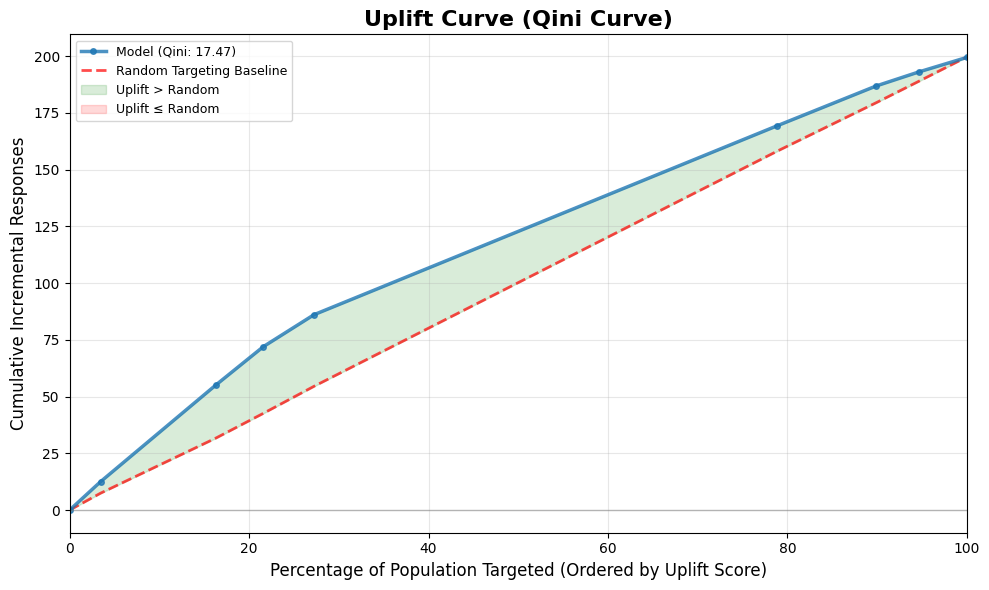

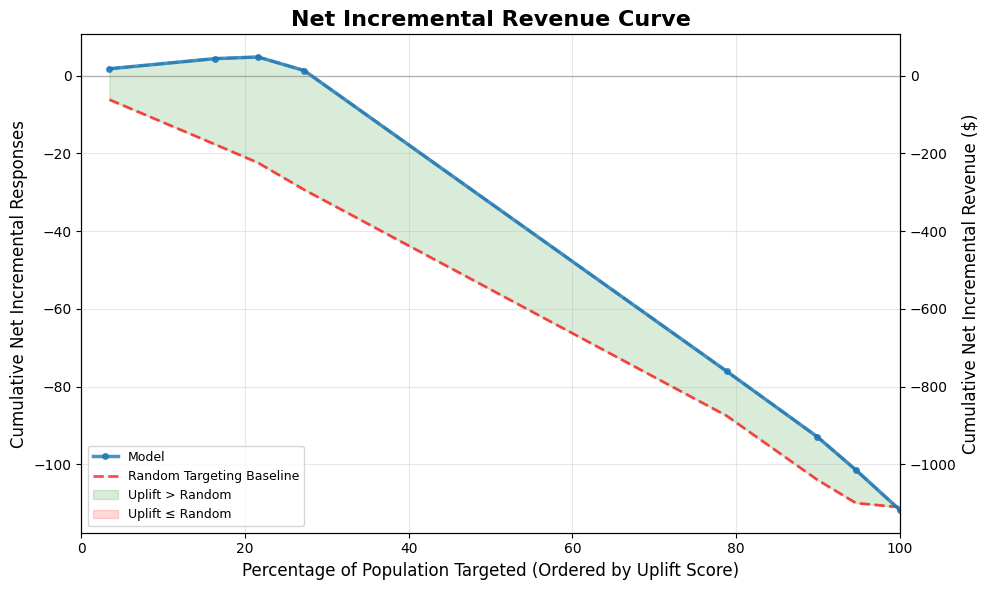

In [52]:
from sklearn.ensemble import RandomForestClassifier

model_treat = RandomForestClassifier(class_weight='balanced', random_state=999)
model_treat.fit(df_treatment[cols], df_treatment['purchase'])

model_control = RandomForestClassifier(class_weight='balanced', random_state=999)
model_control.fit(df_control[cols], df_control['purchase'])

# Predict uplift on validation
prob_treat = model_treat.predict_proba(df_test[cols])[:, 1]
prob_control = model_control.predict_proba(df_test[cols])[:, 1]

df_test['uplift_RF'] = prob_treat - prob_control

lst_uplift_irr.append(calculate_uplift_metrics(df_test, 'uplift_RF', "uplift", n_buckets=20))
plot_uplift_curve(lst_uplift_irr[-1], curve_type="qini")

lst_uplift_nir.append(calculate_uplift_metrics(df_test, 'uplift_RF', "nir", n_buckets=20))
plot_uplift_curve(lst_uplift_nir[-1], curve_type="nir")

#### LR+IPTW：我感觉也是可以用这个线性回归进行预测的，不太行，这是对个体进行预测建模，IPTW是修正整体的问题
这些机器学习模型应该改的是loss，不是真的预测的模型加入IPTW？

/tmp/ipykernel_151803/2042260616.py:10: DtypeWarning: Columns (12,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv('/home/tiger/my_notes/uplift/data/Test.csv')


Training propensity score model...


Plotting propensity score distributions...
Propensity score distribution plot saved to /home/tiger/my_notes/uplift/propensity_score_distribution.png

Running weighted uplift model...


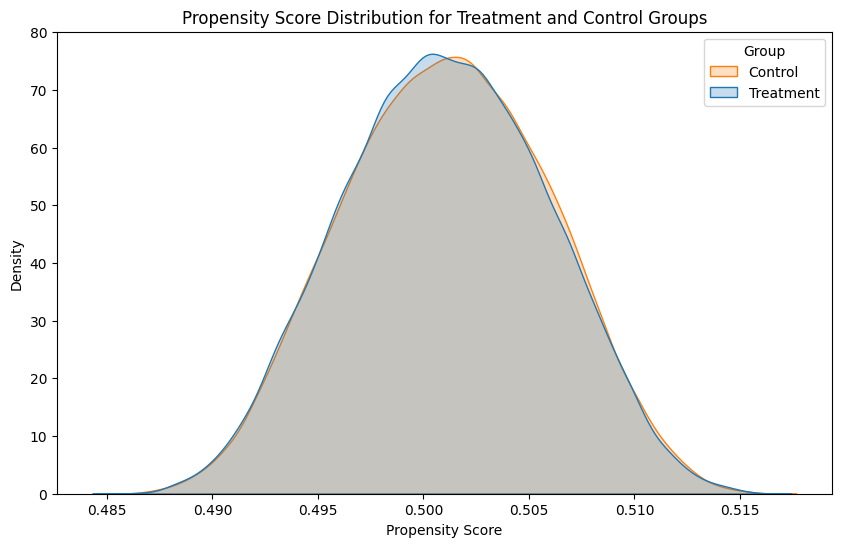

In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_preprocess_data():
    df_train = pd.read_csv('/home/tiger/my_notes/uplift/data/training.csv')
    df_test = pd.read_csv('/home/tiger/my_notes/uplift/data/Test.csv')

    # Preprocess Promotion column
    df_train['Promotion'] = df_train['Promotion'].apply(lambda x: 1 if x == 'Yes' else 0)
    df_test['Promotion'] = df_test['Promotion'].apply(lambda x: 1 if x == 'Yes' else 0)

    # Feature columns
    feature_cols = [f'V{i}' for i in range(1, 8)]

    # Training data
    X_train = df_train[feature_cols]
    y_train = df_train['purchase']
    t_train = df_train['Promotion']

    # Test data
    X_test = df_test[feature_cols]
    y_test = df_test['purchase']
    t_test = df_test['Promotion']
    
    return X_train, y_train, t_train, X_test, y_test, t_test, feature_cols

def train_propensity_model(X_train, t_train):
    """Train a logistic regression model to predict treatment assignment."""
    propensity_model = LogisticRegression()
    propensity_model.fit(X_train, t_train)
    return propensity_model

def plot_propensity_distribution(propensity_scores, t_test):
    """Plot the distribution of propensity scores for treatment and control groups."""
    df_scores = pd.DataFrame({'propensity_score': propensity_scores, 'treatment': t_test})
    
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df_scores, x='propensity_score', hue='treatment', fill=True, common_norm=False)
    plt.title('Propensity Score Distribution for Treatment and Control Groups')
    plt.xlabel('Propensity Score')
    plt.ylabel('Density')
    plt.legend(title='Group', labels=['Control', 'Treatment'])
    plot_path = '/home/tiger/my_notes/uplift/propensity_score_distribution.png'
    plt.savefig(plot_path)
    print(f"Propensity score distribution plot saved to {plot_path}")



def weighted_uplift_model(X_train, y_train, t_train, X_test, propensity_scores_train,weighted=True):
    """Train a weighted logistic regression model and predict uplift."""
    if weighted:
        # Calculate weights (IPTW)
        weights = t_train / propensity_scores_train + (1 - t_train) / (1 - propensity_scores_train)
        
        # Add treatment indicator as a feature
        X_train_with_treatment = X_train.copy()
        X_train_with_treatment['treatment'] = t_train
        
        # Train weighted model
        model = LogisticRegression()
        #为每个样本分配权重
        model.fit(X_train_with_treatment, y_train, sample_weight=weights)
    else:
        # Add treatment indicator as a feature
        X_train_with_treatment = X_train.copy()
        X_train_with_treatment['treatment'] = t_train
        
        # Train weighted model
        model = LogisticRegression()
        #为每个样本分配权重
        model.fit(X_train_with_treatment, y_train)
        
    # Predict on test set
    X_test_treat = X_test.copy()
    X_test_treat['treatment'] = 1
    p_treat = model.predict_proba(X_test_treat)[:, 1]
    
    X_test_control = X_test.copy()
    X_test_control['treatment'] = 0
    p_control = model.predict_proba(X_test_control)[:, 1]
    
    uplift_score = p_treat - p_control
    return uplift_score

X_train, y_train, t_train, X_test, y_test, t_test, _ = load_and_preprocess_data()

#weighted model
# Train propensity score model
print("Training propensity score model...")
propensity_model = train_propensity_model(X_train, t_train)

# Calculate propensity scores on the test set for plotting
propensity_scores_test = propensity_model.predict_proba(X_test)[:, 1]


# Calculate propensity scores on the training set for weighting
propensity_scores_train = propensity_model.predict_proba(X_train)[:, 1]

# 训练集倾向得分密度图
# Plot the distributions
print("Plotting propensity score distributions...")
plot_propensity_distribution(propensity_scores_train, t_train)

# Weighted model
print("\nRunning weighted uplift model...")
uplift_weighted = weighted_uplift_model(X_train, y_train, t_train, X_test, propensity_scores_train)
# no weighted model
uplift_no_weighted = weighted_uplift_model(X_train, y_train, t_train, X_test, propensity_scores_train,weighted=False)


In [66]:
X_test[['Promotion','purchase']]=df_test[['Promotion','purchase']]

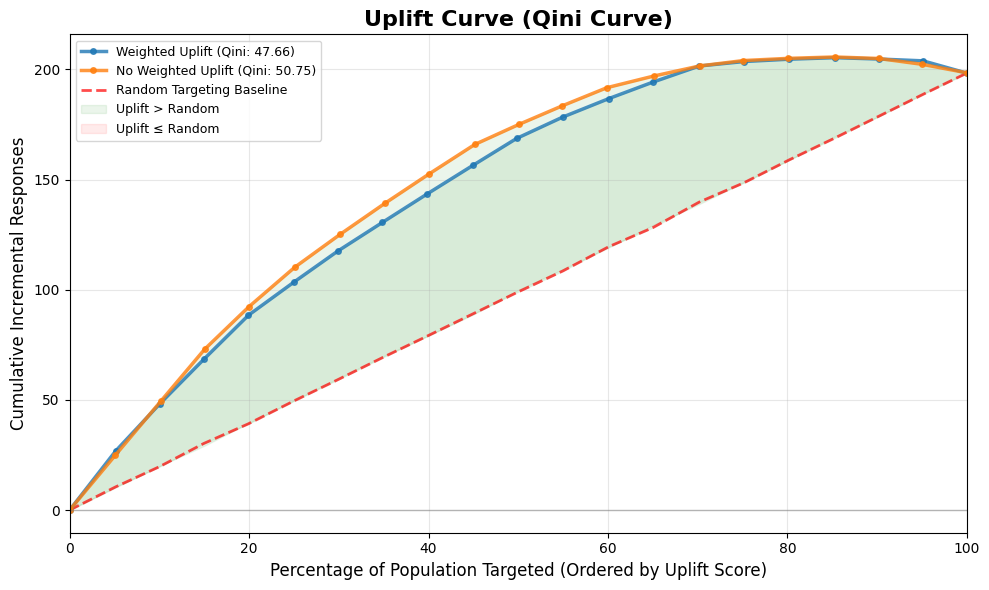

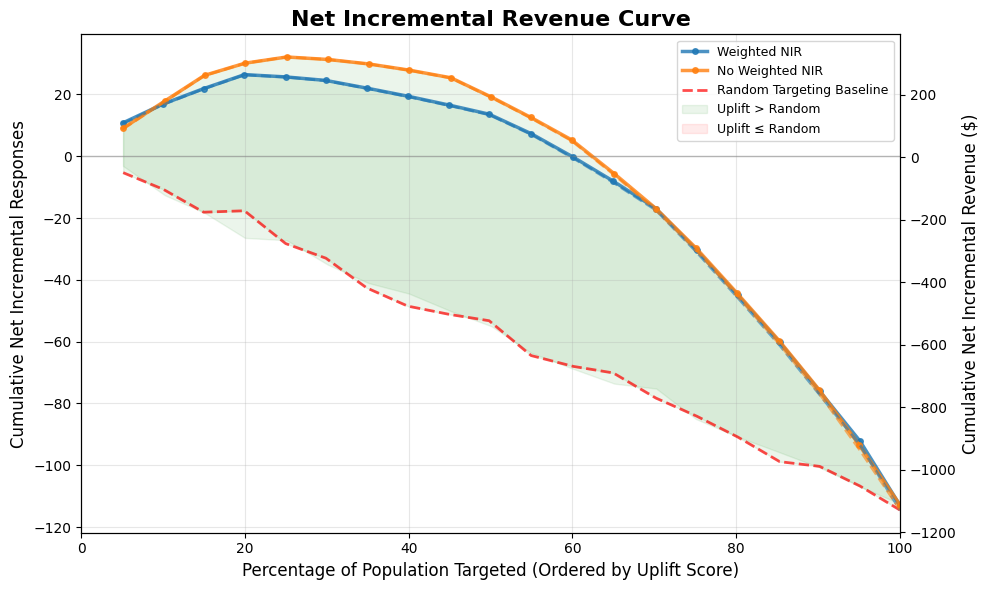

In [69]:
X_test['uplift_RF'] = uplift_weighted
X_test['uplift_no_weighted'] = uplift_no_weighted
cols = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7']

lst_uplift_irr = []
lst_uplift_no_weighted_irr = []
lst_uplift_nir = []
lst_uplift_no_weighted_nir = []

lst_uplift_irr.append(calculate_uplift_metrics(X_test, 'uplift_RF', "uplift", n_buckets=20))
lst_uplift_no_weighted_irr.append(calculate_uplift_metrics(X_test, 'uplift_no_weighted', "uplift", n_buckets=20))
lst_uplift_nir.append(calculate_uplift_metrics(X_test, 'uplift_RF', "nir", n_buckets=20))
lst_uplift_no_weighted_nir.append(calculate_uplift_metrics(X_test, 'uplift_no_weighted', "nir", n_buckets=20))

plot_uplift_curve(
    df=[lst_uplift_irr[-1], lst_uplift_no_weighted_irr[-1]], 
    curve_type="qini",
    labels=['Weighted Uplift', 'No Weighted Uplift']
)

# 绘制 NIR 曲线对比图
plot_uplift_curve(
    df=[lst_uplift_nir[-1], lst_uplift_no_weighted_nir[-1]], 
    curve_type="nir",
    labels=['Weighted NIR', 'No Weighted NIR']
)